# MGT 209 Exercise — Movie Rating Cluster Analysis

**Course:** MGT 209: Marketing Management  
**Session:** Data-based Segmentation and Targeting  
**Exercise:** Clustering consumers' movie ratings  
**Dataset:** `cluster_movies.csv`

## Exercise Background

The Session 5 course introduces **K-means clustering** as a data-based segmentation method. In the movie-rating class exercise, 40 moviegoers who have seen both *Ice Age* and *Rocky* rate each movie on a 0–5 scale.

The course algorithm is:

1. Specify the number of clusters, **K**.
2. Choose K initial centroids.
3. Assign each observation to its closest centroid using **Euclidean distance**.
4. Recompute each cluster centroid.
5. Repeat assignment and recomputation until the centroids stop changing.

### Analytical objective

Use the two movie-rating variables to group moviegoers with similar preference patterns, inspect the resulting centroids, and interpret the segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

DATA_PATH = "/mnt/data/cluster_movies.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(10)


Shape: (40, 3)
Columns: ['Person', 'Ice Age', 'Rocky']


,Person,Ice Age,Rocky
0,1,0.600,0.200
1,2,0.300,0.500
2,3,0.100,0.500
3,4,0.700,0.200
4,5,0.400,0.300
5,6,0.200,0.600
6,7,0.300,0.700
7,8,0.600,0.400
8,9,0.300,0.200
9,10,0.200,0.700


## 1. Data Inspection

`Person` is an identifier and is **not** used as a clustering variable. The two segmentation variables are:

- `Ice Age` — rating from 0 to 5
- `Rocky` — rating from 0 to 5

Because both variables are already measured on the same 0–5 scale, no rescaling is necessary for this exercise.


In [2]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("\nDescriptive statistics:")
display(df[["Ice Age", "Rocky"]].describe().T)


Missing values:


,Missing
Person,0
Ice Age,0
Rocky,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Ice Age,40.000,2.545,2.158,0.000,0.400,2.450,4.725,5.000
Rocky,40.000,2.520,2.045,0.200,0.575,2.500,4.525,5.000


## 2. Visualize the Two-Dimensional Preference Space

With only two clustering variables, the observations can be viewed directly. This makes the movie exercise especially useful for understanding how K-means groups observations according to distance.


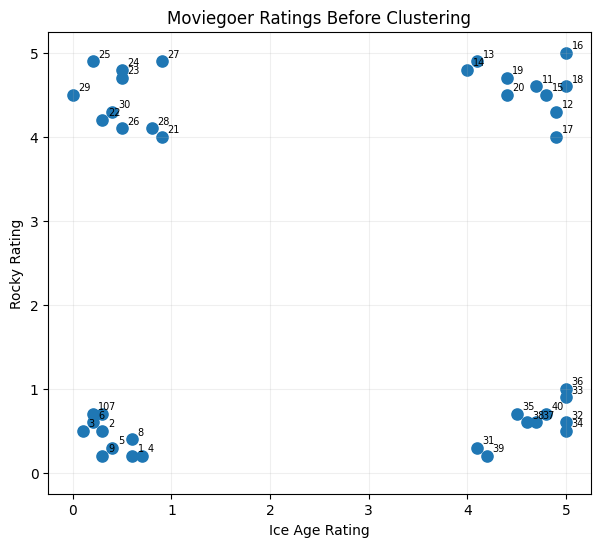

In [3]:
plt.figure(figsize=(7, 6))
plt.scatter(df["Ice Age"], df["Rocky"], s=65)
for _, row in df.iterrows():
    plt.annotate(str(int(row["Person"])), (row["Ice Age"], row["Rocky"]),
                 xytext=(4, 3), textcoords="offset points", fontsize=7)
plt.xlabel("Ice Age Rating")
plt.ylabel("Rocky Rating")
plt.title("Moviegoer Ratings Before Clustering")
plt.xlim(-0.25, 5.25)
plt.ylim(-0.25, 5.25)
plt.grid(alpha=0.2)
plt.show()


## 3. K-means Clustering

The course specifies **K-means with Euclidean distance**. Here, `K = 4` is used because the two-dimensional data visibly contain four separated preference regions. A fixed random seed makes the reproduction deterministic.

The model uses only the two rating variables; `Person` remains an identifier.


In [4]:
features = ["Ice Age", "Rocky"]
X = df[features].copy()

kmeans = KMeans(n_clusters=4, random_state=209, n_init=20)
raw_labels = kmeans.fit_predict(X)
raw_centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)

raw_centers


,Ice Age,Rocky
0,4.690,0.610
1,0.500,4.450
2,0.370,0.430
3,4.620,4.590


### Make cluster labels interpretable

K-means cluster numbers are arbitrary. To make the output easier to read, the raw cluster labels are renamed according to the centroid pattern:

- **Low Both**
- **High Both**
- **Rocky-Oriented**
- **Ice Age-Oriented**

These names are descriptive labels assigned **after** examining the centroids; they are not labels supplied by the course slides.


In [5]:
def profile_name(row):
    ice, rocky = row["Ice Age"], row["Rocky"]
    if ice < 2.5 and rocky < 2.5:
        return "Low Both"
    if ice >= 2.5 and rocky >= 2.5:
        return "High Both"
    if ice < 2.5 and rocky >= 2.5:
        return "Rocky-Oriented"
    return "Ice Age-Oriented"

label_map = {idx: profile_name(row) for idx, row in raw_centers.iterrows()}
df["Segment"] = [label_map[x] for x in raw_labels]

centroids = (
    df.groupby("Segment")[features]
      .mean()
      .reindex(["Low Both", "High Both", "Rocky-Oriented", "Ice Age-Oriented"])
)

sizes = df["Segment"].value_counts().reindex(centroids.index)

print("Cluster sizes:")
display(sizes.to_frame("Moviegoers"))

print("\nCluster centroids:")
display(centroids)


Cluster sizes:


,Moviegoers
Segment,
Low Both,10
High Both,10
Rocky-Oriented,10
Ice Age-Oriented,10



Cluster centroids:


,Ice Age,Rocky
Segment,,
Low Both,0.370,0.430
High Both,4.620,4.590
Rocky-Oriented,0.500,4.450
Ice Age-Oriented,4.690,0.610


## 4. Cluster Assignments

The table below preserves each moviegoer's original ratings and adds the final segment assignment.


In [6]:
assignments = df[["Person", "Ice Age", "Rocky", "Segment"]].sort_values("Person")
display(assignments)


,Person,Ice Age,Rocky,Segment
0,1,0.600,0.200,Low Both
1,2,0.300,0.500,Low Both
2,3,0.100,0.500,Low Both
3,4,0.700,0.200,Low Both
4,5,0.400,0.300,Low Both
5,6,0.200,0.600,Low Both
6,7,0.300,0.700,Low Both
7,8,0.600,0.400,Low Both
8,9,0.300,0.200,Low Both
9,10,0.200,0.700,Low Both


## 5. Visualize the Final Segments

The points are colored by final cluster assignment and the **X** markers show the final cluster centroids.


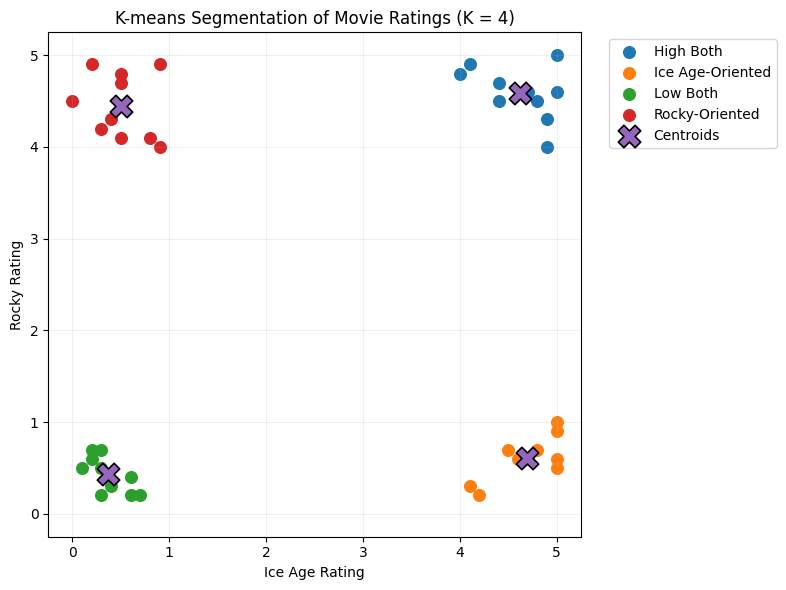

In [7]:
plt.figure(figsize=(8, 6))

for segment, group in df.groupby("Segment"):
    plt.scatter(group["Ice Age"], group["Rocky"], s=70, label=segment)

plt.scatter(centroids["Ice Age"], centroids["Rocky"],
            marker="X", s=260, edgecolor="black", linewidth=1.2,
            label="Centroids")

plt.xlabel("Ice Age Rating")
plt.ylabel("Rocky Rating")
plt.title("K-means Segmentation of Movie Ratings (K = 4)")
plt.xlim(-0.25, 5.25)
plt.ylim(-0.25, 5.25)
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Euclidean Distance Check

K-means assigns each observation to the nearest centroid. The following calculation explicitly reproduces the course logic using Euclidean distance:

\[
d(x,c)=\sqrt{(x_{IceAge}-c_{IceAge})^2+(x_{Rocky}-c_{Rocky})^2}
\]

For each moviegoer, we calculate the distance to all four final centroids and verify that the assigned segment is the nearest one.


In [8]:
segment_order = centroids.index.tolist()
C = centroids.to_numpy()

distance_matrix = np.sqrt(((X.to_numpy()[:, None, :] - C[None, :, :]) ** 2).sum(axis=2))
distance_df = pd.DataFrame(distance_matrix, columns=[f"Distance to {s}" for s in segment_order])

check = pd.concat(
    [df[["Person", "Segment"]].reset_index(drop=True), distance_df],
    axis=1
)
check["Nearest Segment"] = [segment_order[i] for i in distance_matrix.argmin(axis=1)]
check["Assignment Verified"] = check["Segment"] == check["Nearest Segment"]

display(check.head(12))
print("All assignments are to the nearest final centroid:", check["Assignment Verified"].all())


,Person,Segment,Distance to Low Both,Distance to High Both,Distance to Rocky-Oriented,Distance to Ice Age-Oriented,Nearest Segment,Assignment Verified
0,1,Low Both,0.325,5.953,4.251,4.110,Low Both,True
1,2,Low Both,0.099,5.949,3.955,4.391,Low Both,True
2,3,Low Both,0.279,6.096,3.970,4.591,Low Both,True
3,4,Low Both,0.402,5.885,4.255,4.011,Low Both,True
4,5,Low Both,0.133,6.018,4.151,4.301,Low Both,True
5,6,Low Both,0.240,5.955,3.862,4.490,Low Both,True
6,7,Low Both,0.279,5.813,3.755,4.391,Low Both,True
7,8,Low Both,0.232,5.807,4.051,4.095,Low Both,True
8,9,Low Both,0.240,6.159,4.255,4.409,Low Both,True
9,10,Low Both,0.319,5.888,3.762,4.491,Low Both,True


All assignments are to the nearest final centroid: True


## 7. Segment Profiles and Interpretation

The final centroids summarize the average preference pattern within each segment. Because this is a deliberately simple two-variable classroom exercise, the segments can be interpreted directly from their average ratings.


In [9]:
profile = centroids.copy()
profile.insert(0, "Moviegoers", sizes)
profile["Share"] = profile["Moviegoers"] / len(df)
profile["Share"] = profile["Share"].map(lambda x: f"{x:.1%}")
display(profile)


,Moviegoers,Ice Age,Rocky,Share
Segment,,,,
Low Both,10,0.370,0.430,25.0%
High Both,10,4.620,4.590,25.0%
Rocky-Oriented,10,0.500,4.450,25.0%
Ice Age-Oriented,10,4.690,0.610,25.0%


### Interpretation

- **Low Both:** low average ratings for both movies.
- **High Both:** high average ratings for both movies.
- **Rocky-Oriented:** low *Ice Age* ratings and high *Rocky* ratings.
- **Ice Age-Oriented:** high *Ice Age* ratings and low *Rocky* ratings.

In this course dataset, the four groups are highly separated and equal in size. The exercise therefore provides a transparent illustration of **data-based segmentation**: consumers with similar preference patterns are grouped together, while consumers with different preference patterns are separated.

The marketing lesson is not that these four movie segments are universally meaningful. Rather, the exercise demonstrates how observed preference data can be converted into segments that can later be profiled and potentially targeted differently.


## 8. Exercise Takeaways

1. K-means requires the analyst to specify **K**.
2. Each cluster is represented by a **centroid**.
3. Observations are assigned using **Euclidean distance** to the nearest centroid.
4. The centroid is recomputed from the observations assigned to the cluster.
5. Cluster numbers themselves have no substantive meaning; interpretation comes from the resulting **cluster profiles**.
6. In marketing, clustering can support data-based segmentation by identifying groups with similar preferences or needs.

### Source / Provenance

Course-provided instructional dataset `cluster_movies.csv`, used in **MGT 209: Marketing Management**, Session 4/005 — **Data-based Segmentation and Targeting**, UC Riverside, Winter 2023. 